# 📊 Customer Churn – Exploratory Data Analysis

## Objective

The objective of this analysis is to identify key factors influencing customer churn behavior in a telecom dataset.

Churn prediction is treated as a binary classification problem:
- 1 → Customer churned
- 0 → Customer retained

The goal of EDA is to:
- Understand class imbalance
- Identify churn drivers
- Support feature selection for modeling
- Extract actionable business insights

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [2]:
df = pd.read_csv("Data/data_set.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print("Dataset Shape:", df.shape)

print("\nData Types:\n")
print(df.dtypes)

print("\nMissing Values:\n")
print(df.isnull().sum())

Dataset Shape: (7043, 21)

Data Types:

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing Values:

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract  

In [4]:
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

print("Unique values in Churn:", df["Churn"].unique())

Unique values in Churn: [0 1]


Overall Churn Rate: 26.54%


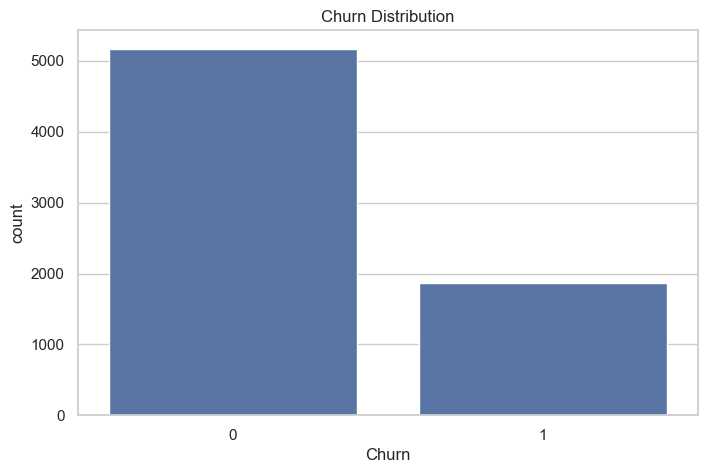

In [5]:
churn_rate = df["Churn"].mean()
print(f"Overall Churn Rate: {churn_rate*100:.2f}%")

sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

Approximately 26–27% of customers churn.

The dataset is moderately imbalanced, making recall and ROC-AUC important evaluation metrics.

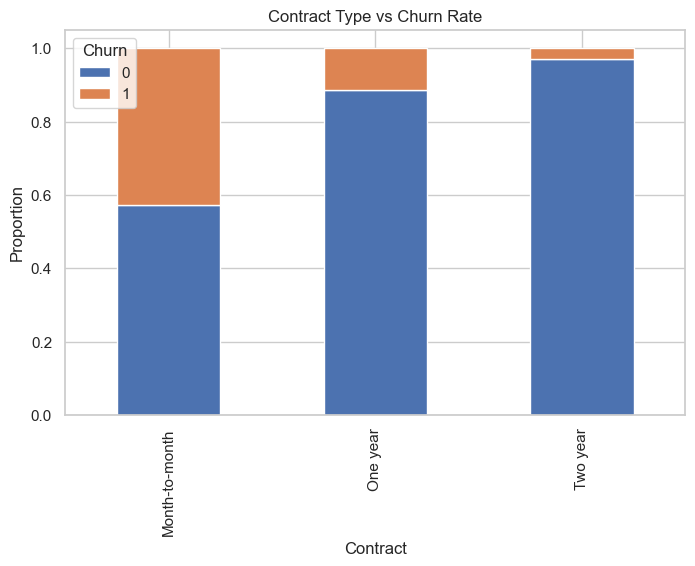

Churn                  0         1
Contract                          
Month-to-month  0.572903  0.427097
One year        0.887305  0.112695
Two year        0.971681  0.028319


In [6]:
contract_churn = pd.crosstab(df["Contract"], df["Churn"], normalize="index")

contract_churn.plot(kind="bar", stacked=True)
plt.title("Contract Type vs Churn Rate")
plt.ylabel("Proportion")
plt.show()

print(contract_churn)

Month-to-month contracts show significantly higher churn rates.

Two-year contracts are the most stable customer segment.

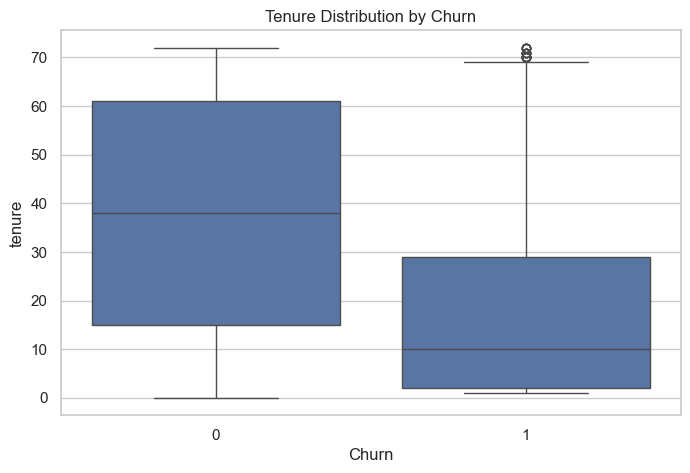

Average Tenure (No Churn): 37.56996521066873
Average Tenure (Churn): 17.979133226324237


In [7]:
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure Distribution by Churn")
plt.show()

print("Average Tenure (No Churn):", df[df["Churn"] == 0]["tenure"].mean())
print("Average Tenure (Churn):", df[df["Churn"] == 1]["tenure"].mean())

Customers with low tenure are significantly more likely to churn.

This suggests early lifecycle risk.

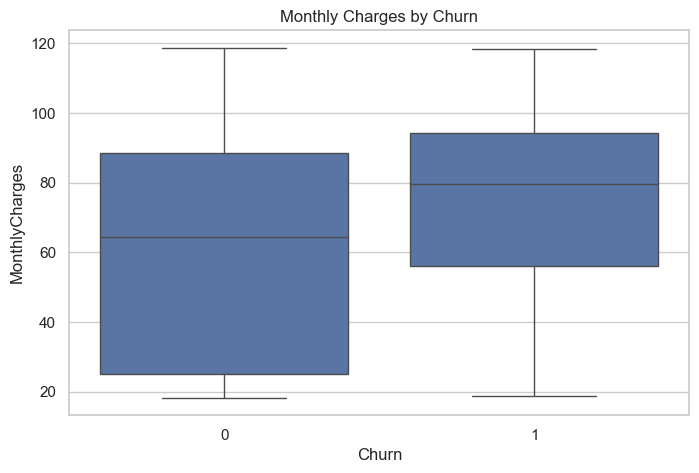

Average Monthly Charges (No Churn): 61.26512369540008
Average Monthly Charges (Churn): 74.44133226324237


In [8]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges by Churn")
plt.show()

print("Average Monthly Charges (No Churn):", df[df["Churn"] == 0]["MonthlyCharges"].mean())
print("Average Monthly Charges (Churn):", df[df["Churn"] == 1]["MonthlyCharges"].mean())

Higher monthly charges are associated with increased churn probability.

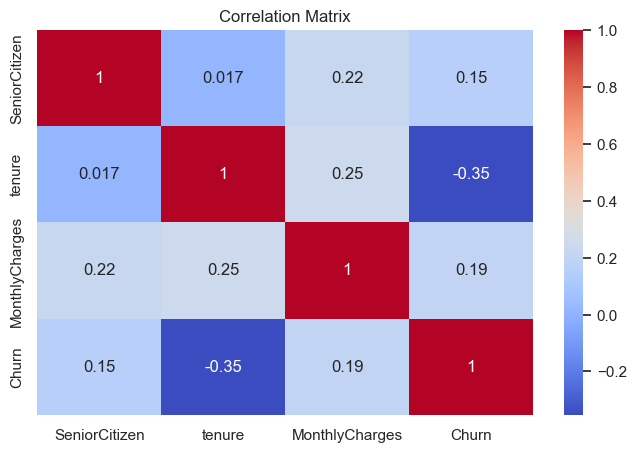

In [9]:
numeric_cols = df.select_dtypes(include=[np.number])

corr_matrix = numeric_cols.corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

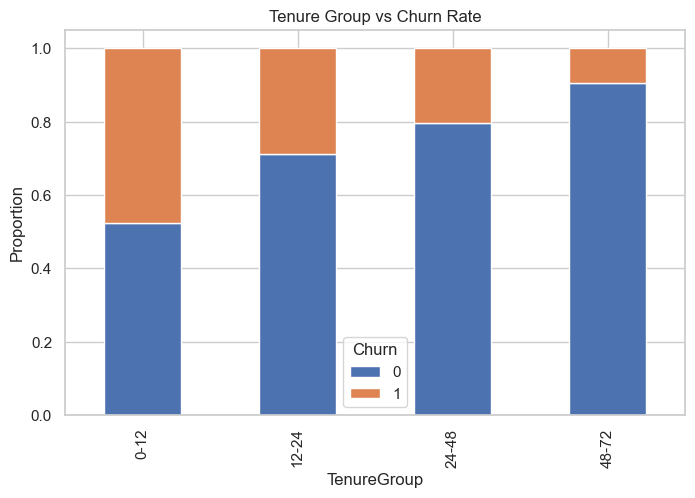

In [10]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-12", "12-24", "24-48", "48-72"]
)

pd.crosstab(df["TenureGroup"], df["Churn"], normalize="index").plot(kind="bar", stacked=True)
plt.title("Tenure Group vs Churn Rate")
plt.ylabel("Proportion")
plt.show()

# 🔍 Key Insights

1. Customers with tenure < 12 months show the highest churn risk.
2. Month-to-month contracts significantly increase churn probability.
3. Higher monthly charges correlate with increased churn likelihood.
4. Two-year contracts represent the most stable customer segment.
5. Class imbalance (~26% churn) requires recall-focused model evaluation.

These findings guided feature selection for the logistic regression model.

## Transition to Modeling

Based on EDA findings, the following features were selected for modeling:

- Tenure
- Monthly Charges
- Contract Type

Logistic Regression was implemented both from scratch (NumPy) and using scikit-learn for performance comparison.